# Deep Neural Network TOTALLY From Scratch for eurosat dataset classification

# Introduction:

## I am doing this project as part of my learning journey in deep learning. Currently, I am taking the Deep Learning Specialization by Deeplearning.AI, and I decided to do this project to make my understanding of the concepts concrete and to improve my overall skills in this lovely path of AI.

## In this project, I am creating a deep neural network from scratch, as well as all of the optimization techniques used to classify the Eurosat (RGB) dataset, consisting of 10 classes.

## I am creating a 5-layer (Input layer + 3 hidden layers + Output layer) Deep Neural Network. This Neural Network will be assisted by the following optimization techniques, which will also be created completely from scratch.

### ** I tried using vectorized implementation in all parts of my code as possible for optimal performance. **

### What I did in this project:

- Relu function
- Softmax function (for output)
- Data handling and cleaning
- Image preprocessing
- Overall Forward Propagation
- Overall Backpropagation
- Implementing Gradient checking to ensure there are no problems with the back propagation
- L2 Regularization technique to avoid variance problems (overfitting)
- Dropout regularization (Inverse Dropout)
- HE Initialization for initializing the hyperparameters efficiently
- (ADAM) Adaptive Moment Estimation Optimization (combining RMSProp and Momentum for the best optimizer possible)
- Learning Rate Decay
- Batching (for faster and more optimized model learning)
- Batch Normalization (for optimizing the training and easing the path for convergence)

#### NOTE: When Batch Normalization is applied, the bias term becomes redundant and can be omitted without loss of generality due to mean normalization. However, it will be kept for completeness of the implementation.

---


![Eurosat dataset classification example](https://miro.medium.com/v2/resize:fit:610/1*i5CK72qCucbH6ots5op86w.jpeg)


## The dataset that I am using is the EuroSAT dataset.

### I will be working on the RGB version where there are 10 classes to be classified:

1. AnnualCrop
2. Forest
3. HerbaceousVegatation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake

#### The dataset is being used for classifying the use of land in geospatial images. Each image in the dataset is 64x64 pixels with a Ground Sampling Distance of 10m. They were all collected from the Sentinel-2 satellite.

#### I am using a ready-to-use split & shuffled version of the dataset (total of 27000 examples). The dataset is split into:

- train.csv ---> 18900 examples
- validation.csv ---> 5400 examples
- test.csv ---> 2700 examples

#### Making the split a 70/20/10 split for the train/validation/test respectively.


## The 5-layer Deep Neural Network Architecture to be implemented:


[![My design for the 5 layer NN architecture to be used](https://i.postimg.cc/jd0QG3qd/5-NN-ARCHITECTURE.jpg)](https://postimg.cc/3W1vGBDP)


## How did I approach the project?

I started by first building each individual function that will build a basic implementation of the forward propagation. So, I created the ReLU, SOFTMAX, and z_func functions, etc. Then I also did all of the necessary preprocessing and data handling on the data so that I can use the data in my model. After that, I implemented a basic forward propagation function then tested it. Getting the output that I expected, I then started working on the cost function and then to the backpropagation. Firstly, I turned the label encoded values that was provided originally by the dataset (column called 'Label') into one-hot encoded values for simpler implementation of backprop. Then I created the cost_func function to calculate the cost function to monitor the performance of the model. Then I implemented the back propagation by getting the grads of each layer then returning the grads. These grads are then passed to an update_grads function, either the classical gradient descent updates or using ADAM Optimizer for better performance (both functions are created). Before I started implementing the ADAM Optimizer, I went back and worked on creating the batching technique, then I tried running a small mini batch of 5 examples to see my progress. I checked my work using gradient checking technique, and after putting in some more work, I managed to get the gradient checking to give me a pass on average and made sure finally that the project is going in the right direction so far (Alhamdulilah). Then I implemented the vanilla gradient update with no optimizers along with ADAM optimizer to get the best results in comparison with the no optimizers one. Next, I worked on the regularization of the model. I implemented L2 regularization and Dropout (with inverse dropout), where both supports inference mode. Lastly, I worked on the hardest problem of the entire project, Batch Normalization. I started by creating function for batch norm forward that is passed between the Z and the activation function, then I adjusted that function to support both training and inference modes using running mean and running variance based on exponential moving average technique (with momentum). I passed the learned parameters beta and gamma to be processed along the forward and back prop to be learned with the weights and biases. Next, the back prop which was the scariest part, but with some help from various sources I got it to work and understood that to reach dZ from dz_telda was based on three routes of differentiation: mean derivation, variance derivation, and the actual derivation of the normalized Z. The final step was to compile everything in the model function, and plot and extract the results, which was done easily as I did this part numerous times in multiple projects, but, I faced a lot of problems within the dimensions of the data and the types, but managed to get them done. 

The most interesting part is when I got everything correct then tried running. The model took ages to run the first 10 epochs (25 minutes). This long time was because of using NumPy which depends solely on CPU and doesn't utilize parallel computation that can be done using Tensorflow. This was a huge problem as I had to optimize the implementation to match that of Tensorflow. So, with a quick search I was introduced to CuPy. This was a great deal for me as I've never known about it, and it was the first time for me using it. Luckily, it was nearly the exact as NumPy, but had to adjust some stuff within the types to avoid limitations of using GPU computations. Also, for some reason this caused the gradient checking to stop working and give ok results.

# Implementation:


## Importing needed libraries


In [1]:
import numpy as np 
import cupy as cp
import pandas as pd 
import warnings
import random
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
# ignoring unwanted warnings for a clean notebook representation
warnings.filterwarnings('ignore')

In [3]:
# Seeding for reproducability
np.random.seed(42)
cp.random.seed(42)
random.seed(42)

## Getting the data ready


In [4]:
train_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/train.csv", index_col=False)
test_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/test.csv", index_col=False)
val_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/validation.csv", index_col=False)

In [5]:
# Dropping unused columns to have a clean Dataframes for training, testing, and validation.

train_data.drop(columns=train_data.columns[[0,3]], axis=1,inplace = True)
test_data.drop(columns=test_data.columns[[0,3]], axis=1,inplace = True)
val_data.drop(columns=val_data.columns[[0,3]], axis=1,inplace = True)

In [6]:
train_data

,Filename,Label
0,AnnualCrop/AnnualCrop_142.jpg,0
1,HerbaceousVegetation/HerbaceousVegetation_2835...,2
2,PermanentCrop/PermanentCrop_1073.jpg,6
3,Industrial/Industrial_453.jpg,4
4,HerbaceousVegetation/HerbaceousVegetation_1810...,2
...,...,...
18895,HerbaceousVegetation/HerbaceousVegetation_1952...,2
18896,Pasture/Pasture_1252.jpg,5
18897,AnnualCrop/AnnualCrop_2332.jpg,0
18898,Residential/Residential_332.jpg,7


In [7]:
test_data

,Filename,Label
0,AnnualCrop/AnnualCrop_1275.jpg,0
1,Residential/Residential_504.jpg,7
2,Pasture/Pasture_787.jpg,5
3,Residential/Residential_1575.jpg,7
4,Pasture/Pasture_473.jpg,5
...,...,...
2695,HerbaceousVegetation/HerbaceousVegetation_516.jpg,2
2696,HerbaceousVegetation/HerbaceousVegetation_855.jpg,2
2697,SeaLake/SeaLake_2696.jpg,9
2698,River/River_472.jpg,8


In [8]:
val_data

,Filename,Label
0,Pasture/Pasture_1481.jpg,5
1,Forest/Forest_2638.jpg,1
2,Highway/Highway_875.jpg,3
3,River/River_434.jpg,8
4,SeaLake/SeaLake_2930.jpg,9
...,...,...
5395,SeaLake/SeaLake_1943.jpg,9
5396,AnnualCrop/AnnualCrop_211.jpg,0
5397,Industrial/Industrial_1428.jpg,4
5398,AnnualCrop/AnnualCrop_2571.jpg,0


### Splitting the data into X and y for preparation of the forward and back props


In [9]:
X_train = train_data.drop(['Label'], axis = 1)
y_train = train_data['Label'].to_numpy()
y_train_gpu = cp.asarray(y_train)

X_val = val_data.drop(['Label'], axis = 1)
y_val = val_data['Label'].to_numpy()
y_val_gpu = cp.asarray(y_val)
X_test = test_data.drop(['Label'], axis = 1)
y_test = test_data['Label'].to_numpy()

In [10]:
train_paths = X_train["Filename"].values
val_paths = X_val["Filename"].values
test_paths = X_test["Filename"].values

### Preprocessing the data by decoding the jpg images to RGB values then normalizing them.


In [11]:
def image_preprocessing(image_paths, size = (64,64)):
    images = []
    base_path = "/kaggle/input/eurosat-dataset/EuroSAT/"
    
    for path in image_paths:
        full_path = os.path.join(base_path, path)
        img = Image.open(f"{full_path}").convert("RGB").resize(size) # Ensuring the same size
        image = cp.array(img, dtype=cp.float32) / 255.0      # Converting to cp.array + Normalizing the values by dividing by 255
        images.append(image)
    return cp.array(images)

In [12]:
m_train = X_train.shape[0]
m_val = X_val.shape[0]
m_test = X_test.shape[0]

X_train_images = image_preprocessing(train_paths).reshape(m_train, -1).T
X_val_images = image_preprocessing(val_paths).reshape(m_val, -1).T
X_test_images = image_preprocessing(test_paths).reshape(m_test, -1).T

X_g_train_images = cp.asarray(X_train_images)
X_g_val_images = cp.asarray(X_val_images)

In [13]:
X_train_images.shape

(12288, 18900)

## Defining the functions to be used


In [14]:
# Z function
def z_func(W,X,b):
    """
    This function is the pre-activation function (AKA weighted sum of inputs) that gets passed into the activation function later.
    W: shape (layer_dims[l], layer_dims[l-1])
    X: shape (layer_dims[l-1], m)
    b: shape (layer_dims[l], 1)

    where:
    m = number of examples
    For the first layer, layer_dims[0] = image_size = 64*64*3
    
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return cp.dot(W, X) + b

In [15]:
# ReLU function
def relu(Z):
    """
    This function is an activation function called ReLU
    Z: shape (num_classes, m) 
    where m = number of examples
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return cp.maximum(0, Z)

In [16]:
def relu_derivative(Z):
    """
    This function derives the relu for the back prop
    Z: shape (num_classes, m)
    where m = number of examples
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return (Z > 0).astype(int) # 1 if Z>0 else 0

In [17]:
# SOFTMAX function
def softmax(Z):
    """
    Z: shape (num_classes, m) 
       where m = number of examples
    
    Returns: probabilities with same shape
    """
    # For numerical stability
    Z_shifted = Z - cp.max(Z, axis=0, keepdims=True)
    exp_Z = cp.exp(Z_shifted)
    return exp_Z / cp.sum(exp_Z, axis=0, keepdims=True)

#### HE Initialization for stable initial values.


In [18]:
def he_initialization(layer_dims = [12288, 512, 256, 128, 10], seed=42):
    """
    layer_dims: list of layer sizes, e.g., [12288, 64, 32, 16, 8, 1]
    The output is a dictionary of initialized parameters and batch norm. stats
    
    Returns: initial values for the weights and biases. Additionaly, it returns gamma, beta, running_mean and running_var parameters for batch normalization implementation.  
    """
    parameters = {}
    bn_parameters = {}
    bn_stats = {}
    L = len(layer_dims)  # number of layers

    for l in range(1, L):
        parameters[f"W{l}"] = cp.random.randn(layer_dims[l], layer_dims[l-1]) * cp.sqrt(2. / layer_dims[l-1]) # HE Initialization in the W parameter
        parameters[f"b{l}"] = cp.zeros((layer_dims[l], 1)) # can be initialized by all zeros because it won't affect the stability
    
        # Debug check
        #print(f"W{l}.shape = {parameters[f'W{l}'].shape}, b{l}.shape = {parameters[f'b{l}'].shape}")
    for l in range(1,L-1):
        bn_parameters[f"gamma{l}"] = cp.ones((layer_dims[l], 1))
        bn_parameters[f"beta{l}"] = cp.zeros((layer_dims[l], 1))
        bn_stats["running_mean" + str(l)] = cp.zeros((layer_dims[l], 1))
        bn_stats["running_var" + str(l)] = cp.ones((layer_dims[l], 1))

    return parameters, bn_parameters, bn_stats

In [19]:
# he_initialization([12288, 512, 256, 128, 10])

In [20]:
# Forward Propagation Implementation
def forward_propagation(parameters, X, keep_prob = 0.5, training = True):
    """
    parameters: dictionary of the initial weights, biases
    X: shape (layer_dims[l-1], m)
    keep_prob: dropout regularization hyperparameter that gets compared with a random number generated for each hidden layer to decide whether to drop or keep the node 
    training: flag that makes sure regularization is only applied in training and not during evaluation (true = apply , false = don't apply)
    
    Returns: the cache from the forward propagation and the parameters used.
    """
    if not training:
        keep_prob = 1
   
    # Layer 2     
    z_1 = z_func(parameters['W1'],X,parameters['b1'])
    a_1 = relu(z_1)
    d_1 = cp.random.rand(a_1.shape[0], a_1.shape[1]) < keep_prob
    a_1 *= d_1 
    a_1 /= keep_prob  # inverted dropout to ensure the expected value of Z to be consistent even if the layer had some dropouts
    
    # Layer 3
    z_2 = z_func(parameters['W2'],a_1,parameters['b2'])
    a_2 = relu(z_2)
    d_2 = cp.random.rand(a_2.shape[0], a_2.shape[1]) < keep_prob
    a_2 *= d_2 
    a_2 /= keep_prob

    # Layer 4
    z_3 = z_func(parameters['W3'],a_2,parameters['b3'])
    a_3 = relu(z_3)
    d_3 = cp.random.rand(a_3.shape[0], a_3.shape[1]) < keep_prob
    a_3 *= d_3 
    a_3 /= keep_prob

    # Layer 5
    z_4 = z_func(parameters['W4'],a_3,parameters['b4'])
    a_4 = softmax(z_4)

    cache = {"X": X,"z_1": z_1, "a_1": a_1, "z_2": z_2, "a_2": a_2, "z_3": z_3, "a_3": a_3, "z_4": z_4, "a_4": a_4, "d_1": d_1, "d_2": d_2, "d_3": d_3}
    return a_4, cache, parameters
    

In [21]:
# Batch Normalization Forward Propagation
def batch_normalization_forward(Z, gamma, beta, r_mean, r_var, training, epsilon=1e-7, momentum=0.9):
    """
    Z: the pre-activation function (AKA weighted sum of inputs) that gets passed into the activation function later.
    parameters: dictionary of the initial gamma and beta
    bn_stats: dictionary of the initial running_mean and running_var
    training: flag that makes sure we handle training mode and inference mode of Batch Norm. (true = apply , false = don't apply)

    Returns: the normalized-scaled value of Z to get passed to the activation function
    
    """

    if training:
        
        m = cp.mean(Z, axis=1, keepdims=True)
        v = cp.var(Z, axis=1, keepdims=True)
        z_n = (Z-m)/cp.sqrt(v + epsilon)
        r_mean = (momentum * r_mean) + (1-momentum) * m
        r_var = (momentum * r_var) + (1-momentum) * v

        cache = {"z_n": z_n, "m":m, "v":v, "gamma": gamma, "beta": beta, "r_mean": r_mean, "r_var": r_var}

    else:
        z_n = (Z - r_mean) / cp.sqrt(r_var + epsilon)
        cache = None

    z_t = (gamma * z_n) + beta

    return z_t, cache

In [22]:
# Forward Propagation Implementation
def forward_propagation_with_BN(parameters, bn_parameters, bn_stats, X, keep_prob = 0.5, training = True):
    """
    parameters: dictionary of the initial weights and biases
    X: shape (layer_dims[l-1], m)
    keep_prob: dropout regularization hyperparameter that gets compared with a random number generated for each hidden layer to decide whether to drop or keep the node 
    training: flag that makes sure regularization is only applied in training and not during evaluation (true = apply , false = don't apply)
    
    Returns: the cache from the forward propagation and the parameters used.
    """
    if not training:
        keep_prob = 1
   
    # Layer 2     
    z_1 = z_func(parameters['W1'],X,parameters['b1'])
    z_t_1, cache_1 = batch_normalization_forward(z_1, bn_parameters["gamma1"], bn_parameters["beta1"], bn_stats["running_mean1"], bn_stats["running_var1"], training, epsilon=1e-7)
    if training:
        bn_stats["running_mean1"] = cache_1["r_mean"]
        bn_stats["running_var1"] = cache_1["r_var"]
    a_1 = relu(z_t_1)
    d_1 = cp.random.rand(a_1.shape[0], a_1.shape[1]) < keep_prob
    a_1 *= d_1 
    a_1 /= keep_prob  # inverted dropout to ensure the expected value of Z to be consistent even if the layer had some dropouts
    
    # Layer 3
    z_2 = z_func(parameters['W2'],a_1,parameters['b2'])
    z_t_2, cache_2 = batch_normalization_forward(z_2, bn_parameters["gamma2"], bn_parameters["beta2"], bn_stats["running_mean2"], bn_stats["running_var2"], training, epsilon=1e-7)
    if training:
        bn_stats["running_mean2"] = cache_2["r_mean"]
        bn_stats["running_var2"] = cache_2["r_var"]
    a_2 = relu(z_t_2)
    d_2 = cp.random.rand(a_2.shape[0], a_2.shape[1]) < keep_prob
    a_2 *= d_2 
    a_2 /= keep_prob

    # Layer 4
    z_3 = z_func(parameters['W3'],a_2,parameters['b3'])
    z_t_3, cache_3 = batch_normalization_forward(z_3, bn_parameters["gamma3"], bn_parameters["beta3"], bn_stats["running_mean3"], bn_stats["running_var3"], training, epsilon=1e-7)
    if training:
        bn_stats["running_mean3"] = cache_3["r_mean"]
        bn_stats["running_var3"] = cache_3["r_var"]
    a_3 = relu(z_t_3)
    d_3 = cp.random.rand(a_3.shape[0], a_3.shape[1]) < keep_prob
    a_3 *= d_3 
    a_3 /= keep_prob

    # Layer 5
    z_4 = z_func(parameters['W4'],a_3,parameters['b4'])
    a_4 = softmax(z_4)

    cache = {"X": X, "z_1": z_1, "z_t_1": z_t_1, "a_1": a_1, "z_2": z_2, "z_t_2": z_t_2, "a_2": a_2, "z_3": z_3, "z_t_3": z_t_3, "a_3": a_3, "z_4": z_4, "a_4": a_4, "d_1": d_1, "d_2": d_2, "d_3": d_3, "bn_cache_1": cache_1,"bn_cache_2": cache_2,"bn_cache_3": cache_3}
    return a_4, cache, parameters
    

In [23]:
def one_hot_encode(y, num_classes):
    """
    This function takes in the target y and the number of classes and converts them from label-encoded values to one-hot encoded values for easier handling in the loss function and backpropagation.
    
    Returns: one_hot encoded values of the target values.
    """
    y = y.flatten()  # make sure y is 1D: (m,)
    m = y.shape[0]   # number of examples
    one_hot = cp.zeros((num_classes, m))
    one_hot[y, cp.arange(m)] = 1
    return one_hot
    
enc_y_train = one_hot_encode(y_train, 10)
enc_y_val = one_hot_encode(y_val, 10)
enc_y_test = one_hot_encode(y_test, 10)
print(enc_y_train.shape)

(10, 18900)


In [24]:
def cost_func(X, y, parameters, bn_parameters=None, bn_stats=None, lambd=0.01, 
              keep_prob=1.0, training=True):
    """
    The function returns the cost function with l2 regularization after the forward propagation for performance monitoring and supports batch normalization
    
    X: shape (layer_dims[l-1], m)
    y: the true label of the examples from the training set. shape: (num_classes, m)
    lambd: l2 regularization hyperparameter that adjusts the regularization strength
    training: flag that makes sure regularization is only applied in training and not during evaluation (true = apply , false = don't apply)

    Returns: the cost function value for monitoring and evaluation.

    cost: the cost result of the predictions
    """

    # Choose forward propagation based on whether BN parameters exist
    if bn_parameters is not None:
        y_pred, _, _ = forward_propagation_with_BN(parameters, bn_parameters, bn_stats, 
                                                     X, keep_prob, training)
    else:
        y_pred, _, _ = forward_propagation(parameters, X, training=training)
    
    m = y.shape[1]
    
    l2_cost = 0
    if training:
        for l in range(1, 5):
            l2_cost += np.sum(np.square(parameters["W" + str(l)]))
    
    epsilon = 1e-7
    cost = (-np.sum(y * np.log(y_pred + epsilon)) / m) + (lambd / (2 * m) * l2_cost)
    
    return np.squeeze(cost)  

In [25]:
def back_prop(cache, parameters, y_train, lambd = 0.01, keep_prob = 0.5, training = True):
    """
    The function implements the backpropagation for the model.
    
    cache: dictionary of the values from the forward propagation to get the gradients.
    y_train: the true label of the examples from the training set. shape: (num_classes, m) 
    lambd: l2 regularization hyperparameter that adjusts the regularization strength
    training: flag that makes sure regularization is only applied in training and not during evaluation (true = apply , false = don't apply)

    Returns:

    grads: dictionary that contains the resulted gradients from the back propagation process
    """
    m = y_train.shape[1]

    if not training:
        keep_prob = 1

    # Layer 5
    dz_4 = cache['a_4'] - y_train # for output layer SOFTMAX use dZ[L]=A[L]−Y directly as a shortcut for the derivative
    dw_4 = cp.dot(dz_4, cache['a_3'].T) / m + ((lambd/m) * (parameters["W4"]))*training
    db_4 = cp.sum(dz_4, axis = 1, keepdims = True) / m

    # Layer 4
    da_3 = cp.dot(parameters["W4"].T, dz_4)
    d_3 = cache['d_3']
    da_3 = da_3 * d_3 / keep_prob
    dz_3 = cp.multiply(da_3, relu_derivative(cache['z_3']))
    dw_3 = cp.dot(dz_3, cache['a_2'].T) / m + ((lambd/m) * (parameters["W3"]))*training
    db_3 = cp.sum(dz_3, axis = 1, keepdims = True) / m
    
    # Layer 3
    da_2 = cp.dot(parameters["W3"].T, dz_3)
    d_2 = cache['d_2']
    da_2 = da_2 * d_2 / keep_prob
    dz_2 = cp.multiply(da_2, relu_derivative(cache['z_2']))
    dw_2 = cp.dot(dz_2, cache['a_1'].T) / m + ((lambd/m) * (parameters["W2"]))*training
    db_2 = cp.sum(dz_2, axis = 1, keepdims = True) / m

    # Layer 2
    da_1 = cp.dot(parameters["W2"].T, dz_2)
    d_1 = cache['d_1']
    da_1 = da_1 * d_1 / keep_prob
    dz_1 = cp.multiply(da_1, relu_derivative(cache['z_1']))
    dw_1 = cp.dot(dz_1, cache['X'].T) / m + ((lambd/m) * (parameters["W1"]))*training
    db_1 = cp.sum(dz_1, axis = 1, keepdims = True) / m

    grads = {'dw_4': dw_4, 'db_4': db_4, 'dw_3': dw_3, 'db_3': db_3, 'dw_2': dw_2, 'db_2': db_2, 'dw_1': dw_1, 'db_1': db_1}
    return grads

In [26]:
# Batch Normalization Backpropagation
def batch_normalization_backward(dz_tilde, cache, layer, epsilon=1e-7):
    """
    dz_tilde: the derivation of the z_tilde expression, which is the output of the batch normalization in forward prop
    cache: dictionary of the values from the forward propagation to get the gradients
    layer: the layer where the BN backprop is passing through (1-3)

    Returns:

    bn_grads: dictionary that contains the resulted gradients from the back propagation process    
    """
    m = dz_tilde.shape[1] 

    dgamma = cp.sum(dz_tilde * cache[f"bn_cache_{layer}"]["z_n"], axis = 1, keepdims= True)
    dbeta = cp.sum(dz_tilde, axis = 1, keepdims= True)
    dz_n = dz_tilde * cache[f"bn_cache_{layer}"]["gamma"]

    term1 = m * dz_n
    term2 = cp.sum(dz_n, axis = 1, keepdims = True)
    term3 = cache[f"bn_cache_{layer}"]["z_n"] * cp.sum(dz_n * cache[f"bn_cache_{layer}"]["z_n"], axis = 1, keepdims= True)

    dZ = (1. / (m * cp.sqrt(cache[f"bn_cache_{layer}"]["v"] + epsilon))) * (term1 - term2 - term3)

    bn_grads = {"dgamma" : dgamma, "dbeta" : dbeta, "dz": dZ}

    return dZ, bn_grads


In [27]:
def back_prop_with_BN(cache, parameters, y_train, lambd = 0.01, keep_prob = 0.5, training = True):
    """
    The function implements the backpropagation for the model with batch normalization integrated.
    
    cache: dictionary of the values from the forward propagation to get the gradients.
    y_train: the true label of the examples from the training set. shape: (num_classes, m) 
    lambd: l2 regularization hyperparameter that adjusts the regularization strength
    training: flag that makes sure regularization is only applied in training and not during evaluation (true = apply , false = don't apply)

    Returns:

    grads: dictionary that contains the resulted gradients from the back propagation process
    """
    m = y_train.shape[1]

    if not training:
        keep_prob = 1

    # Layer 5
    dz_4 = cache['a_4'] - y_train # for output layer SOFTMAX use dZ[L]=A[L]−Y directly as a shortcut for the derivative
    dw_4 = cp.dot(dz_4, cache['a_3'].T) / m + ((lambd/m) * (parameters["W4"]))*training
    db_4 = cp.sum(dz_4, axis = 1, keepdims = True) / m

    # Layer 4
    da_3 = cp.dot(parameters["W4"].T, dz_4)
    d_3 = cache['d_3']
    da_3 = da_3 * d_3 / keep_prob
    dz_t_3 = da_3 * relu_derivative(cache["z_t_3"])
    dz_3, bn_grads_3 = batch_normalization_backward(dz_t_3, cache, 3, epsilon=1e-7)
    dw_3 = cp.dot(dz_3, cache['a_2'].T) / m + ((lambd/m) * (parameters["W3"]))*training
    db_3 = cp.sum(dz_3, axis = 1, keepdims = True) / m
    
    # Layer 3
    da_2 = cp.dot(parameters["W3"].T, dz_3)
    d_2 = cache['d_2']
    da_2 = da_2 * d_2 / keep_prob
    dz_t_2 = da_2 * relu_derivative(cache["z_t_2"])
    dz_2, bn_grads_2 = batch_normalization_backward(dz_t_2, cache, 2, epsilon=1e-7)
    dw_2 = cp.dot(dz_2, cache['a_1'].T) / m + ((lambd/m) * (parameters["W2"]))*training
    db_2 = cp.sum(dz_2, axis = 1, keepdims = True) / m

    # Layer 2
    da_1 = cp.dot(parameters["W2"].T, dz_2)
    d_1 = cache['d_1']
    da_1 = da_1 * d_1 / keep_prob
    dz_t_1 = da_1 * relu_derivative(cache["z_t_1"])
    dz_1, bn_grads_1 = batch_normalization_backward(dz_t_1, cache, 1, epsilon=1e-7)
    dw_1 = cp.dot(dz_1, cache['X'].T) / m + ((lambd/m) * (parameters["W1"]))*training
    db_1 = cp.sum(dz_1, axis = 1, keepdims = True) / m

    grads = {'dw_4': dw_4, 'db_4': db_4, 'dw_3': dw_3, 'db_3': db_3, 'dw_2': dw_2, 'db_2': db_2, 'dw_1': dw_1, 'db_1': db_1, "bn_grads_3": bn_grads_3, "bn_grads_2": bn_grads_2, "bn_grads_1": bn_grads_1}
    return grads

### Functions for Gradient Checking:


In [28]:
def params_to_vector(params):
    """
    params: dict of numpy arrays in correct order, e.g. {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2, ...}
    
    Returns:
    
    theta: (n,1) column vector of all params concatenated
    keys: list of keys in order
    shapes: list of shapes for each key
    """
    keys = []
    shapes = []
    vecs = []
    for k, v in params.items():             # rely on insertion order
        keys.append(k)
        shapes.append(v.shape)
        vecs.append(v.reshape(-1, 1))
    theta = np.concatenate(vecs, axis=0)
    return theta, keys, shapes

In [29]:
def vector_to_params(theta, keys, shapes):
    """
    theta: (n,1) column vector
    keys, shapes: as returned by params_to_vector
    
    Returns:
    
    params: dict mapping keys -> numpy arrays of original shapes
    """
    params = {}
    idx = 0
    for k, s in zip(keys, shapes):
        size = int(np.prod(s))
        slice_ = theta[idx: idx + size]
        params[k] = slice_.reshape(s)
        idx += size
    return params

In [30]:
def grads_to_vector(grads, keys):
    """
    grads: dict of gradients, e.g. {'dw_1': ..., 'db_1': ...}
    keys: list of param keys, e.g. ['W1','b1','W2','b2',...]
    
    Returns: grad_vector (n,1)
    """
    vecs = []
    keys = sorted(params.keys())
    for k in keys:
        if k.startswith("W"):
            grad_key = "dw_" + k[1:]   # "W1" -> "dw_1"
        elif k.startswith("b"):
            grad_key = "db_" + k[1:]   # "b1" -> "db_1"
        else:
            raise KeyError(f"Unexpected key format: {k}")
        
        v = grads[grad_key]
        vecs.append(v.reshape(-1, 1))
    
    return np.concatenate(vecs, axis=0)

In [31]:
def gradient_check(params, grads, X_train, y_train, epsilon = 1e-7, print_msg = True):
    X_train = cp.asarray(X_train)
    y_train = cp.asarray(y_train)

    param_values, keys, shapes = params_to_vector(params)
    param_values = param_values.reshape(-1) 
    grad_values = grads_to_vector(grads, keys)
    
    num_params = param_values.shape[0]
    
    J_plus = cp.zeros((num_params, 1))
    J_minus = cp.zeros((num_params, 1))
    gradapprox = cp.zeros((num_params, 1))
    
    indices_to_check = cp.random.choice(num_params, 10, replace=False) 
    
    for i in indices_to_check:
        theta_plus = cp.copy(param_values).reshape(-1)
        theta_plus[i] = theta_plus[i] + epsilon
        J_plus[i] = cost_func(X_train, y_train, vector_to_params(theta_plus, keys, shapes), lambd = 0.01, training = False)

        theta_minus = cp.copy(param_values).reshape(-1)
        theta_minus[i] = theta_minus[i] - epsilon
        J_minus[i] = cost_func(X_train, y_train, vector_to_params(theta_minus, keys, shapes), lambd = 0.01, training = False)   

        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2 * epsilon)

    # Compute norms on GPU
    numerator = cp.linalg.norm(grad_values[indices_to_check] - gradapprox[indices_to_check])
    denominator = cp.linalg.norm(grad_values[indices_to_check]) + cp.linalg.norm(gradapprox[indices_to_check])
    difference = numerator / denominator

    # Move results back to CPU for printing and logical comparison
    diff_val = float(difference)
    grad_norm_val = float(cp.linalg.norm(grad_values))
    approx_norm_val = float(cp.linalg.norm(gradapprox))

    print(f"grad_values norm: {grad_norm_val}")
    print(f"gradapprox norm: {approx_norm_val}")

    if print_msg:
        if diff_val > 2e-7:
            print ("\033[93m" + f"There is a mistake in the backward propagation! difference = {diff_val}" + "\033[0m")
        else:
            print ("\033[92m" + f"Your backward propagation works perfectly fine! difference = {diff_val}" + "\033[0m")

    return diff_val

### Trying the Gradient Checking on the first 5 examples to ensure the backpropagation is correctly implemented:


In [32]:
# Trying the Gradient Checking on the first 5 examples to ensure the backpropagation is correctly implemented:

params, _, _ = he_initialization()
X_batch = X_g_train_images[:, :5]

y_batch = enc_y_train[:, :5]
ex_5_pred, ex_5_cache, ex_5_params = forward_propagation(params, X_batch, keep_prob = 1, training = False)
ex_5_grads = back_prop(ex_5_cache, ex_5_params, y_batch, lambd = 0.01, keep_prob = 1, training = False)
gradient_check(ex_5_params, ex_5_grads, X_batch, y_batch, 1e-7, True)

grad_values norm: 22.373599662642636
gradapprox norm: 0.03808896326620192
There is a mistake in the backward propagation! difference = 9.201002933973316e-07


9.201002933973316e-07

**_The Gradient above may not exactly be less than 2 _ 10^-7, and according to my understanding the backprop is correct, but there are small intricacies that cause the value not to reach the value needed. This maybe but not exclusive to float accuracy, computational infinitesimal errors, numerical precision limits of the GPU or a layer-specific indexing mismatch in the gradient check loop\***


In [33]:
def create_mini_batches(X, y, batch_size):
    m = X.shape[1]
    permutation = list(cp.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_y = y[:, permutation]
    
    mini_batches = []
    num_complete_minibatches = m // batch_size

    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * batch_size : (k + 1) * batch_size]
        mini_batch_Y = shuffled_y[:, k * batch_size : (k + 1) * batch_size]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    if m % batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * batch_size : ]
        mini_batch_Y = shuffled_y[:, num_complete_minibatches * batch_size : ]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    return mini_batches

### Updating the Parameters after ensuring backpropagation implementation using a vanilla parameter update with no optimization, then an Adaptive Moment Estimation Optimizer for comparison.


In [34]:
def update_parameters(parameters, grads, bn_parameters= None, lr = 0.001):
    """
    The function is responsible for updating the parameters with the new gradients that came from the back propagation function with classic gradient descent updates.

    parameters: dictionary of weights and biases to be updated
    grads: dictionary of the gradients that will be used to update the parameters    
    lr: learning rate value. (initially 0.001)
    """

    new_parameters = {}
    new_parameters_bn = {} 

    for l in range(1,5):
        new_parameters[f"W{l}"] = parameters[f"W{l}"] - lr * grads[f"dw_{l}"]
        new_parameters[f"b{l}"] = parameters[f"b{l}"] - lr * grads[f"db_{l}"]

    # For Batch Norm parameters:

    if bn_parameters:
        for l in range(1,4):
            layer_key = f"bn_grads_{l}"
            if layer_key in grads:
                new_parameters_bn[f"gamma{l}"] = bn_parameters[f"gamma{l}"] - lr * grads[layer_key]["dgamma"]
                new_parameters_bn[f"beta{l}"] = bn_parameters[f"beta{l}"] - lr * grads[layer_key]["dbeta"]

    return new_parameters, new_parameters_bn

In [35]:
# old implementation without using loops



#def update_parameters_ADAM(parameters, grads, bn_parameters= None, lr = 0.001, beta_m = 0.9, beta_rms = 0.999, t = 2):
#    '''
#    The function is responsible for updating the parameters with the new gradients that came from the back propagation function utilizing the Adaptive Moment Estimation optimizer that basically integrates the Momentum and RMSprop optimizers into one robust optimizer with bias correction.
#
#    parameters: dictionary of weights and biases to be updated
#    grads: dictionary of the gradients that will be used to update the parameters    
#    lr: learning rate value. (initially 0.001)
#    beta_m: the parameter beta used with the Momentum using exponentially weighted averages optimizer to update the gradients
#    beta_rms: the parameter beta used with the RMSprop optimizer to update the gradients
#    '''
#    
#    new_parameters = {}
#    Vdw_4, Vdb_4, Vdw_3, Vdb_3, Vdw_2, Vdb_2, Vdw_1, Vdb_1 = 0,0,0,0,0,0,0,0
#    Sdw_4, Sdb_4, Sdw_3, Sdb_3, Sdw_2, Sdb_2, Sdw_1, Sdb_1 = 0,0,0,0,0,0,0,0 
#    epsilon = 1e-7
#    
#    # Layer 5
#    
#    Vdw_4 = beta_m * Vdw_4 + (1 - beta_m) * grads["dw_4"]
#    Vdb_4 = beta_m * Vdb_4 + (1 - beta_m) * grads["db_4"]
#    Vdw_4_corr = Vdw_4 / (1-(beta_m ** t)) # bias correction implementation to avoid bias-related systematic errors
#    Vdb_4_corr = Vdb_4 / (1-(beta_m ** t))
#    
#    Sdw_4 = beta_rms * Sdw_4 + (1 - beta_rms) * (grads["dw_4"] ** 2)
#    Sdb_4 = beta_rms * Sdb_4 + (1 - beta_rms) * (grads["db_4"] ** 2)
#    Sdw_4_corr = Sdw_4 / (1-(beta_rms ** t))
#    Sdb_4_corr = Sdb_4 / (1-(beta_rms ** t))
#    
#    new_parameters["W4"] = parameters["W4"] - lr * (Vdw_4_corr /((Sdw_4_corr ** 0.5) + epsilon))
#    new_parameters["b4"] = parameters["b4"] - lr * (Vdb_4_corr /((Sdb_4_corr ** 0.5) + epsilon))
#
#    # Layer 4
#
#    Vdw_3 = beta_m * Vdw_3 + (1 - beta_m) * grads["dw_3"]
#    Vdb_3 = beta_m * Vdb_3 + (1 - beta_m) * grads["db_3"]
#    Vdw_3_corr = Vdw_3 / (1-(beta_m ** t))
#    Vdb_3_corr = Vdb_3 / (1-(beta_m ** t))
#    
#    Sdw_3 = beta_rms * Sdw_3 + (1 - beta_rms) * (grads["dw_3"] ** 2)
#    Sdb_3 = beta_rms * Sdb_3 + (1 - beta_rms) * (grads["db_3"] ** 2)
#    Sdw_3_corr = Sdw_3 / (1-(beta_rms ** t))
#    Sdb_3_corr = Sdb_3 / (1-(beta_rms ** t))
#    
#    new_parameters["W3"] = parameters["W3"] - lr * (Vdw_3_corr /((Sdw_3_corr ** 0.5) + epsilon))
#    new_parameters["b3"] = parameters["b3"] - lr * (Vdb_3_corr /((Sdb_3_corr ** 0.5) + epsilon))
#
#    # Layer 3
#
#    Vdw_2 = beta_m * Vdw_2 + (1 - beta_m) * grads["dw_2"]
#    Vdb_2 = beta_m * Vdb_2 + (1 - beta_m) * grads["db_2"]
#    Vdw_2_corr = Vdw_2 / (1-(beta_m ** t))
#    Vdb_2_corr = Vdb_2 / (1-(beta_m ** t))
#    
#    Sdw_2 = beta_rms * Sdw_2 + (1 - beta_rms) * (grads["dw_2"] ** 2)
#    Sdb_2 = beta_rms * Sdb_2 + (1 - beta_rms) * (grads["db_2"] ** 2)
#    Sdw_2_corr = Sdw_2 / (1-(beta_rms ** t))
#    Sdb_2_corr = Sdb_2 / (1-(beta_rms ** t))
#    
#    new_parameters["W2"] = parameters["W2"] - lr * (Vdw_2_corr /((Sdw_2_corr ** 0.5) + epsilon))
#    new_parameters["b2"] = parameters["b2"] - lr * (Vdb_2_corr /((Sdb_2_corr ** 0.5) + epsilon))
#
#    # Layer 2
#
#    Vdw_1 = beta_m * Vdw_1 + (1 - beta_m) * grads["dw_1"]
#    Vdb_1 = beta_m * Vdb_1 + (1 - beta_m) * grads["db_1"]
#    Vdw_1_corr = Vdw_1 / (1-(beta_m ** t))
#    Vdb_1_corr = Vdb_1 / (1-(beta_m ** t))
#    
#    Sdw_1 = beta_rms * Sdw_1 + (1 - beta_rms) * (grads["dw_1"] ** 2)
#    Sdb_1 = beta_rms * Sdb_1 + (1 - beta_rms) * (grads["db_1"] ** 2)
#    Sdw_1_corr = Sdw_1 / (1-(beta_rms ** t))
#    Sdb_1_corr = Sdb_1 / (1-(beta_rms ** t))
#    
#    new_parameters["W1"] = parameters["W1"] - lr * (Vdw_1_corr /((Sdw_1_corr ** 0.5) + epsilon))
#    new_parameters["b1"] = parameters["b1"] - lr * (Vdb_1_corr /((Sdb_1_corr ** 0.5) + epsilon))
#
#    
#
#    return new_parameters


In [36]:
def initialize_adam_parameters(parameters, bn_parameters=None):
    """
    Initializes the velocity (V) and squared gradient (S) dictionaries for ADAM optimizer.
    
    parameters: dictionary of weights and biases {'W1', 'b1', 'W2', 'b2', ...}
    bn_parameters: dictionary of batch norm parameters {'gamma1', 'beta1', ...} (optional)
    
    Returns: Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta initialization dictionaries for the Adam optimizer
    """
    
    Vdw = {}
    Vdb = {}
    Sdw = {}
    Sdb = {}
    
    # Initialize for regular parameters (4 layers)
    for l in range(1, 5):
        Vdw[f"W{l}"] = cp.zeros_like(parameters[f"W{l}"])
        Vdb[f"b{l}"] = cp.zeros_like(parameters[f"b{l}"])
        Sdw[f"W{l}"] = cp.zeros_like(parameters[f"W{l}"])
        Sdb[f"b{l}"] = cp.zeros_like(parameters[f"b{l}"])
    
    # Initialize for batch normalization parameters (3 layers)
    Vdgamma = {}
    Vdbeta = {}
    Sdgamma = {}
    Sdbeta = {}
    
    if bn_parameters:
        for l in range(1, 4):
            Vdgamma[f"gamma{l}"] = cp.zeros_like(bn_parameters[f"gamma{l}"])
            Vdbeta[f"beta{l}"] = cp.zeros_like(bn_parameters[f"beta{l}"])
            Sdgamma[f"gamma{l}"] = cp.zeros_like(bn_parameters[f"gamma{l}"])
            Sdbeta[f"beta{l}"] = cp.zeros_like(bn_parameters[f"beta{l}"])
    
    return Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta

In [37]:
def update_parameters_ADAM(parameters, grads, Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta, bn_parameters = None, lr = 0.001, beta_m = 0.9, beta_rms = 0.999, t = 2):
    """
    The function is responsible for updating the parameters with the new gradients that came from the back propagation function utilizing the Adaptive Moment Estimation optimizer that basically integrates the Momentum and RMSprop optimizers into one robust optimizer with bias correction.

    parameters: dictionary of weights and biases to be updated
    grads: dictionary of the gradients that will be used to update the parameters    
    lr: learning rate value. (initially 0.001)
    beta_m: the parameter beta used with the Momentum using exponentially weighted averages optimizer to update the gradients
    beta_rms: the parameter beta used with the RMSprop optimizer to update the gradients
    t: parameter for bias correction (epoch number)
    """
    
    new_parameters = {}
    new_parameters_bn = {}
    epsilon = 1e-7
    
    for l in range(1,5):
        Vdw[f"W{l}"] = beta_m * Vdw[f"W{l}"] + (1 - beta_m) * grads[f"dw_{l}"]
        Vdb[f"b{l}"] = beta_m * Vdb[f"b{l}"] + (1 - beta_m) * grads[f"db_{l}"]
        Vdw_corr = Vdw[f"W{l}"]/(1-(beta_m ** t)) # bias correction implementation to avoid bias-related systematic errors
        Vdb_corr = Vdb[f"b{l}"]/(1-(beta_m ** t))

        Sdw[f"W{l}"] = beta_rms * Sdw[f"W{l}"] + (1 - beta_rms) * (grads[f"dw_{l}"] ** 2)
        Sdb[f"b{l}"] = beta_rms * Sdb[f"b{l}"] + (1 - beta_rms) * (grads[f"db_{l}"] ** 2)
        Sdw_corr = Sdw[f"W{l}"]/(1-(beta_rms ** t))
        Sdb_corr = Sdb[f"b{l}"]/(1-(beta_rms ** t))

        new_parameters[f"W{l}"] = parameters[f"W{l}"] - lr * (Vdw_corr/((Sdw_corr ** 0.5) + epsilon))
        new_parameters[f"b{l}"] = parameters[f"b{l}"] - lr * (Vdb_corr/((Sdb_corr ** 0.5) + epsilon))


    # For Batch Normalization parameters:

    if bn_parameters:
        for l in range(1,4):
            layer_key = f"bn_grads_{l}"
            if layer_key in grads:
                Vdgamma[f"gamma{l}"] = beta_m * Vdgamma[f"gamma{l}"] + (1 - beta_m) * grads[layer_key]["dgamma"]
                Vdbeta[f"beta{l}"] = beta_m * Vdbeta[f"beta{l}"] + (1 - beta_m) * grads[layer_key]["dbeta"]
                Vdgamma_corr = Vdgamma[f"gamma{l}"]/(1-(beta_m ** t))
                Vdbeta_corr = Vdbeta[f"beta{l}"]/(1-(beta_m ** t))

                Sdgamma[f"gamma{l}"] = beta_rms * Sdgamma[f"gamma{l}"] + (1 - beta_rms) * (grads[layer_key]["dgamma"] ** 2)
                Sdbeta[f"beta{l}"] = beta_rms * Sdbeta[f"beta{l}"] + (1 - beta_rms) * (grads[layer_key]["dbeta"] ** 2)
                Sdgamma_corr = Sdgamma[f"gamma{l}"]/(1-(beta_rms ** t))
                Sdbeta_corr = Sdbeta[f"beta{l}"]/(1-(beta_rms ** t))

                new_parameters_bn[f"gamma{l}"] = bn_parameters[f"gamma{l}"] - lr * (Vdgamma_corr/((Sdgamma_corr ** 0.5) + epsilon))
                new_parameters_bn[f"beta{l}"] = bn_parameters[f"beta{l}"] - lr * (Vdbeta_corr/((Sdbeta_corr ** 0.5) + epsilon))

    return new_parameters, new_parameters_bn, Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta


In [38]:
def schedule_lr_decay(learning_rate0, epoch_num, decay_rate, time_interval=25):
    """
    Calculates updated the learning rate using exponential weight decay with fixed interval scheduling.

    learning_rate0 : Original learning rate. Scalar
    epoch_num : Epoch number. Integer.
    decay_rate : Decay rate. Scalar.
    time_interval : Number of epochs to update the learning rate.

    Returns:
    learning_rate : Updated learning rate. Scalar 
    """
    learning_rate = 1 / (1 + (decay_rate * cp.floor(epoch_num/time_interval))) * learning_rate0
    
    return learning_rate

### Functions to plot the learning curve and the confusion matrix of the Model


In [39]:
def plot_learning_curves(train_costs, val_costs, train_acc, val_acc, save_path=None):
    """
    Plots Cost and Accuracy in side-by-side subplots.
    Handles both lists (history) and scalars (final values) for accuracy.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # --- Subplot 1: Cost (Loss) ---
    ax[0].plot([float(c) for c in train_costs], label='train')
    ax[0].plot([float(c) for c in val_costs], label='validation')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Cost')
    ax[0].set_title('Cost vs Epoch')
    ax[0].legend()

    # --- Subplot 2: Accuracy ---
    
    def is_sequence(x):
        if isinstance(x, list):
            return True
        if isinstance(x, np.ndarray):
            return x.ndim > 0  
        return False

    # Plot Train Accuracy
    if is_sequence(train_acc):
        ax[1].plot([float(c) for c in train_acc], label='train')
    else:
        ax[1].axhline(y=float(train_acc), color='tab:blue', label=f'Final Train Acc: {float(train_acc):.2f}%')

    # Plot Validation Accuracy
    if is_sequence(val_acc):
        ax[1].plot([float(c) for c in val_acc], label='validation')
    else:
        ax[1].axhline(y=float(val_acc), color='tab:orange', linestyle='--', label=f'Final Val Acc: {float(val_acc):.2f}%')
    ax[1].set_ylim([0, 100])
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Accuracy vs Epoch')
    ax[1].legend()

    if save_path:
        plt.savefig(save_path + 'loss_accuracy_curve.png')

    plt.tight_layout()
    plt.show()

In [40]:
def plot_euro_sat_confusion_matrix(y_true, y_pred):
    class_names = [
        "AnnualCrop", "Forest", "HerbaceousVeg", "Highway", "Industrial",
        "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
    ]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: EuroSAT Classes')
    plt.show()

# Prediction:


## Model function that implements the Deep Neural Network


In [41]:
def model(X, Y, X_val, Y_val, layers_dims, optimizer="adam", learning_rate=0.0007, 
          mini_batch_size=64, num_epochs=100, lambd=0.3, keep_prob=0.5, 
          decay_rate=1, print_cost=True):
    
    m = X.shape[1]
    train_accs = []
    val_accs   = []
    train_costs = []
    val_costs = []    
    t = 0
    
    parameters, bn_parameters, bn_stats = he_initialization(layers_dims)
    Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta = initialize_adam_parameters(parameters, bn_parameters)
    learning_rate0 = learning_rate

    for i in range(1, num_epochs + 1):
        cost_total = 0
        minibatches = create_mini_batches(X, Y, mini_batch_size)
        
        for minibatch in minibatches:
            minibatch_X, minibatch_Y = minibatch
            
            al, cache, _ = forward_propagation_with_BN(
                parameters, bn_parameters, bn_stats, 
                minibatch_X, keep_prob, training=True
            )
            
            batch_cost = cost_func(minibatch_X, minibatch_Y, parameters, 
                       bn_parameters, bn_stats, lambd, keep_prob, training=True)
            cost_total += batch_cost
            
            grads = back_prop_with_BN(cache, parameters, minibatch_Y, lambd, keep_prob, training=True)
            
            if optimizer == "adam":
                t += 1
                parameters, bn_parameters, Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta = update_parameters_ADAM(
                    parameters, grads, Vdw, Vdb, Sdw, Sdb, Vdgamma, Vdbeta, Sdgamma, Sdbeta,
                    bn_parameters, learning_rate, beta_m=0.9, beta_rms=0.999, t=t
                )
            else:
                parameters, bn_parameters = update_parameters(parameters, grads, bn_parameters, learning_rate)
        
        learning_rate = schedule_lr_decay(learning_rate0, i, decay_rate)
        
        cost_avg = cost_total / len(minibatches)
        train_costs.append(float(cost_avg))
        
        val_cost = cost_func(X_val, Y_val, parameters, bn_parameters, bn_stats, lambd=0, training=False)
        val_costs.append(float(val_cost))
        
        # --- NEW ACCURACY COMPUTATION ---
        # 1. Forward pass on the full training set (inference mode)
        train_preds, _, _ = forward_propagation_with_BN(
            parameters, bn_parameters, bn_stats, X, keep_prob=1.0, training=False
        )
        # 2. Forward pass on the full validation set (inference mode)
        val_preds, _, _ = forward_propagation_with_BN(
            parameters, bn_parameters, bn_stats, X_val, keep_prob=1.0, training=False
        )
        
        # Calculate accuracy (.argmax and .mean work natively on both NumPy and CuPy)
        train_acc = (train_preds.argmax(axis=0) == Y.argmax(axis=0)).mean()
        val_acc = (val_preds.argmax(axis=0) == Y_val.argmax(axis=0)).mean()
        
        train_accs.append(float(train_acc))
        val_accs.append(float(val_acc))
        
        if print_cost and i % 10 == 0:
            print(f"Epoch {i}: Train Cost = {cost_avg:.4f} | Val Cost = {val_cost:.4f} | Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f} | LR = {learning_rate:.6f}")

    return parameters, bn_parameters, bn_stats, train_costs, val_costs, train_accs, val_accs

In [42]:
def predict(X, parameters, bn_parameters, bn_stats):
    
    # Run forward prop in inference mode (no dropout, uses running stats for Batch Norm)
    probas, _, _ = forward_propagation_with_BN(
        parameters, bn_parameters, bn_stats, X, 
        keep_prob=1, training=False
    )
    
    # Pick the class with the highest probability (0-9)
    predictions = cp.argmax(probas, axis=0)
    
    return predictions

In [43]:
final_params, final_bn_params, final_bn_stats, train_costs, val_costs, train_accs, val_accs = model(
    X = X_train_images,
    Y = enc_y_train,
    X_val = X_val_images,   
    Y_val = enc_y_val,        
    layers_dims = [12288, 512, 256, 128, 10],
    optimizer = "adam",
    learning_rate = 0.0007,
    mini_batch_size = 32,
    num_epochs = 140,
    lambd = 0.3,
    keep_prob = 0.5,
    decay_rate = 1,
    print_cost = True
)

train_predictions = predict(X_train_images, final_params, final_bn_params, final_bn_stats)
val_predictions = predict(X_val_images, final_params, final_bn_params, final_bn_stats)

Epoch 10: Train Cost = 2.1597 | Val Cost = 2.9897 | Train Acc = 0.2464 | Val Acc = 0.2491 | LR = 0.000700
Epoch 20: Train Cost = 2.1556 | Val Cost = 2.0601 | Train Acc = 0.2930 | Val Acc = 0.2907 | LR = 0.000700
Epoch 30: Train Cost = 1.8992 | Val Cost = 1.4574 | Train Acc = 0.4754 | Val Acc = 0.4706 | LR = 0.000350
Epoch 40: Train Cost = 1.8617 | Val Cost = 1.4831 | Train Acc = 0.4436 | Val Acc = 0.4443 | LR = 0.000350
Epoch 50: Train Cost = 1.8464 | Val Cost = 1.4636 | Train Acc = 0.4567 | Val Acc = 0.4541 | LR = 0.000233
Epoch 60: Train Cost = 1.6938 | Val Cost = 1.7716 | Train Acc = 0.4349 | Val Acc = 0.4331 | LR = 0.000233
Epoch 70: Train Cost = 1.6793 | Val Cost = 1.4781 | Train Acc = 0.4572 | Val Acc = 0.4487 | LR = 0.000233
Epoch 80: Train Cost = 1.6112 | Val Cost = 1.4943 | Train Acc = 0.4708 | Val Acc = 0.4656 | LR = 0.000175
Epoch 90: Train Cost = 1.5906 | Val Cost = 1.1900 | Train Acc = 0.5991 | Val Acc = 0.5894 | LR = 0.000175
Epoch 100: Train Cost = 1.5906 | Val Cost = 1.

### Exporting the model for deployment:

In [44]:
import pickle

numpy_params = {k: cp.asnumpy(v) for k, v in final_params.items()}
numpy_bn_params = {k: cp.asnumpy(v) for k, v in final_bn_params.items()} if final_bn_params else {}
numpy_bn_stats = {k: cp.asnumpy(v) for k, v in final_bn_stats.items()} if final_bn_stats else {}

clean_train_costs = [float(x) for x in train_costs]
clean_val_costs = [float(x) for x in val_costs]
clean_train_accs = [float(x) for x in train_accs]
clean_val_accs = [float(x) for x in val_accs]

dnn_model_data_cpu = {
    'parameters': numpy_params,
    'bn_parameters': numpy_bn_params,
    'bn_stats': numpy_bn_stats,
    'architecture': [12288, 512, 256, 128, 10],
    'hyperparams': {
        'lambd': 0.3,
        'keep_prob': 0.5
    },
    'train_costs': clean_train_costs,
    'val_costs': clean_val_costs,
    'train_accs': clean_train_accs,
    'val_accs': clean_val_accs
}

with open('DNN_scratch_cpu.pkl', 'wb') as f:
    pickle.dump(dnn_model_data_cpu, f)

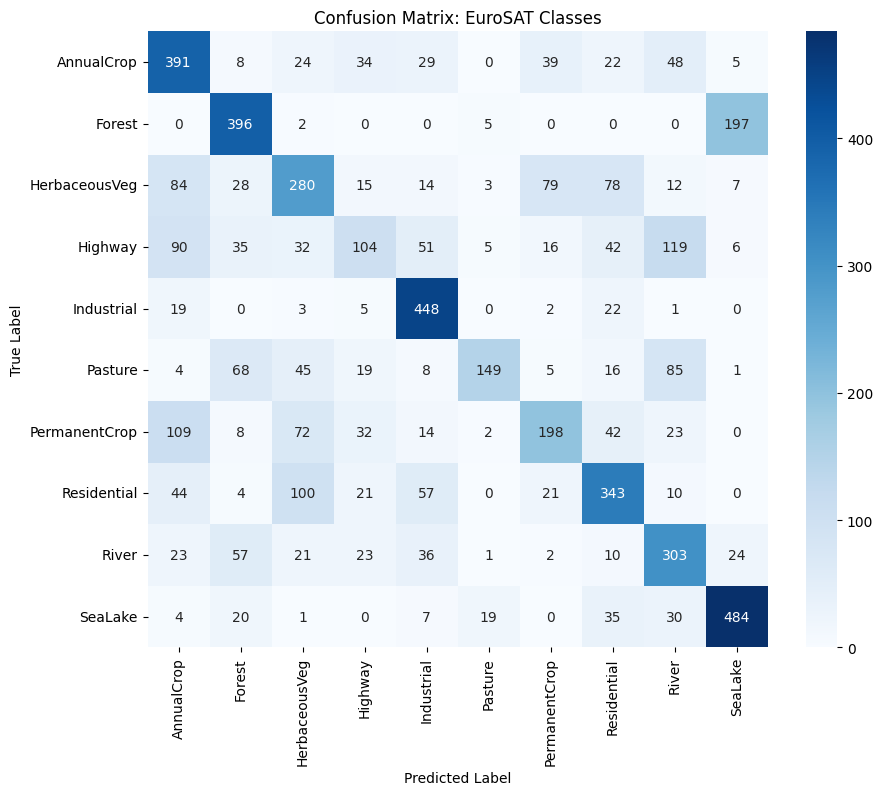

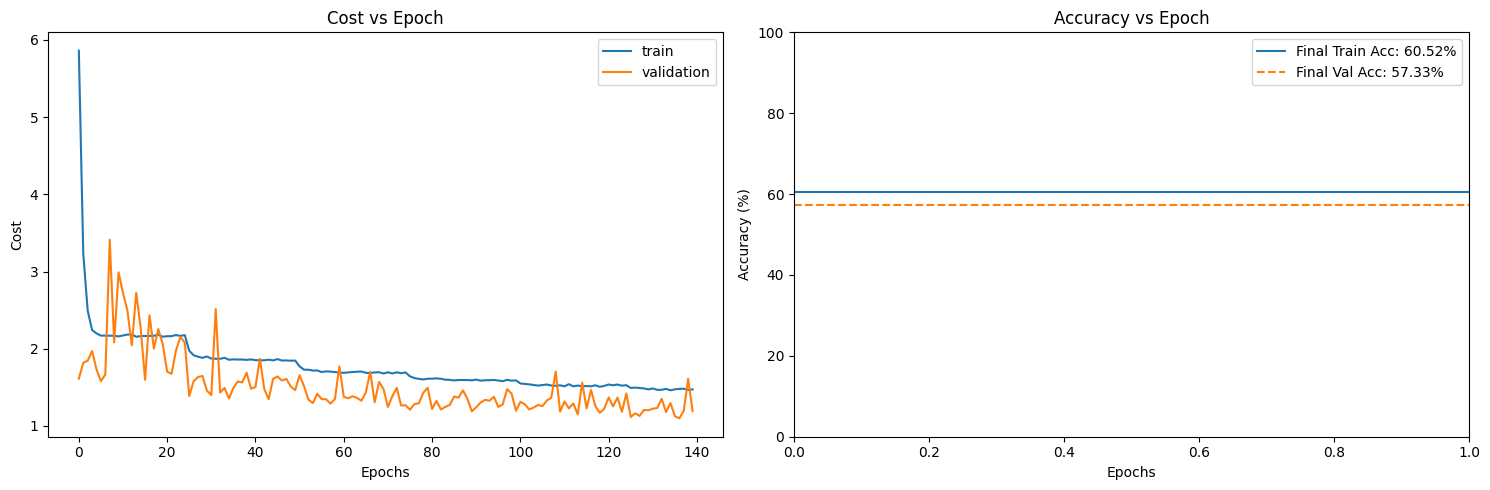

Training Accuracy: 60.52%
Validation Accuracy: 57.33%


In [45]:
# Compute accuracies
train_accuracy = cp.mean(train_predictions == y_train_gpu) * 100
val_accuracy = cp.mean(val_predictions == y_val_gpu) * 100

val_predictions_c = cp.asnumpy(val_predictions)
train_accuracy_c = cp.asnumpy(train_accuracy)
val_accuracy_c = cp.asnumpy(val_accuracy)

# Plot confusion matrix
plot_euro_sat_confusion_matrix(y_val, val_predictions_c)

# Plot learning curves
plot_learning_curves(train_costs, val_costs, train_accuracy_c, val_accuracy_c)

print(f"Training Accuracy: {float(train_accuracy):.2f}%")
print(f"Validation Accuracy: {float(val_accuracy):.2f}%")

### Test Accuracy 

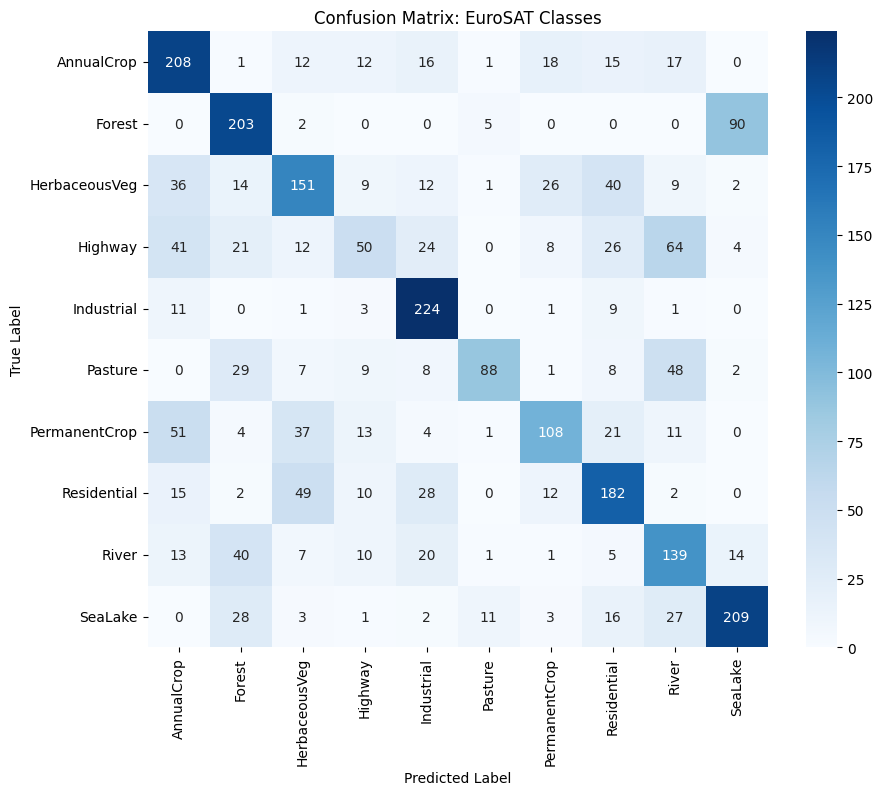

Test Accuracy: 57.85%


In [46]:
test_predictions = predict(X_test_images, final_params, final_bn_params, final_bn_stats)

test_predictions_c = cp.asnumpy(test_predictions)

test_accuracy = (test_predictions_c == y_test).mean() * 100

plot_euro_sat_confusion_matrix(y_test, test_predictions_c)

print(f"Test Accuracy: {test_accuracy:.2f}%")

# Implementing a library-ready model using Tensorflow for comparison:


In [47]:
import tensorflow as tf

X_train_images_transposed = X_train_images.T
X_val_images_transposed = X_val_images.T
X_test_images_transposed = X_test_images.T
X_train_reshaped = cp.asnumpy(X_train_images_transposed.reshape(-1, 64, 64, 3))
X_val_reshaped = cp.asnumpy(X_val_images_transposed.reshape(-1, 64, 64, 3))
X_test_reshaped = cp.asnumpy(X_test_images_transposed.reshape(-1, 64, 64, 3))
enc_y_train_transposed = cp.asnumpy(enc_y_train.T)
enc_y_val_transposed = cp.asnumpy(enc_y_val.T)
enc_y_test_transposed = cp.asnumpy(enc_y_test.T)

# CHANGED: Reduced L2 from 0.07 to 0.001
l2_reg = tf.keras.regularizers.l2(0.001)

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
    tf.keras.layers.Dense(512, activation = "relu", kernel_regularizer=l2_reg, kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(epsilon=1e-7),
    tf.keras.layers.Dropout(0.4), 
    
    tf.keras.layers.Dense(256, activation = "relu", kernel_regularizer=l2_reg, kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(epsilon=1e-7),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Dense(128, activation = "relu", kernel_regularizer=l2_reg, kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(epsilon=1e-7),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Dense(10, activation = "softmax", kernel_regularizer=l2_reg)
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)

batch_size=32
steps_per_epoch = len(X_train_images_transposed) // batch_size
initial_learning_rate = 0.0007
decay_steps_interval = steps_per_epoch * 25

# CHANGED: Switched from ExponentialDecay to InverseTimeDecay
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps_interval,
    decay_rate=1.0,
    staircase=True) 

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer,
              loss= loss_fn,
              metrics = ['accuracy']
             )

print("Training the model ...")

history = model.fit(
    X_train_reshaped, 
    enc_y_train_transposed, 
    epochs=140, 
    batch_size=32,
    validation_data=(X_val_reshaped, enc_y_val_transposed)
)

2026-03-04 22:34:02.374007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772663642.586620      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772663642.642666      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1772663655.930131      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7675 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training the model ...
Epoch 1/140


I0000 00:00:1772663664.138894      62 service.cc:148] XLA service 0x2ee85370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772663664.139642      62 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772663664.649788      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


 38/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1573 - loss: 4.7231

I0000 00:00:1772663667.752232      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


591/591 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.2594 - loss: 3.7672 - val_accuracy: 0.2361 - val_loss: 3.5661
Epoch 2/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3983 - loss: 2.5320 - val_accuracy: 0.2420 - val_loss: 4.5584
Epoch 3/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4166 - loss: 2.2214 - val_accuracy: 0.1041 - val_loss: 5.5364
Epoch 4/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4437 - loss: 2.0194 - val_accuracy: 0.1820 - val_loss: 3.9408
Epoch 5/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4485 - loss: 2.0156 - val_accuracy: 0.3365 - val_loss: 2.5592
Epoch 6/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4490 - loss: 2.0641 - val_accuracy: 0.3583 - val_loss: 2.8048
Epoch 7/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4538 - loss: 2.1067 - val_accuracy: 0.4780 - val_loss: 2.0611
Epoch 8/140
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4359 - loss: 2.1452 - val_accuracy: 0.24

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


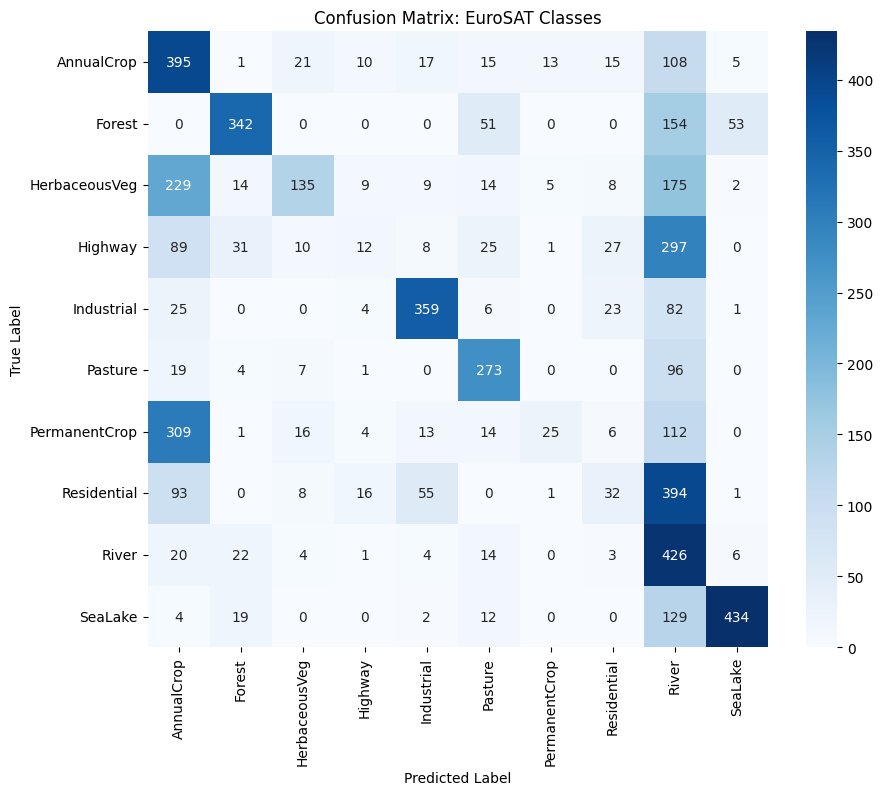

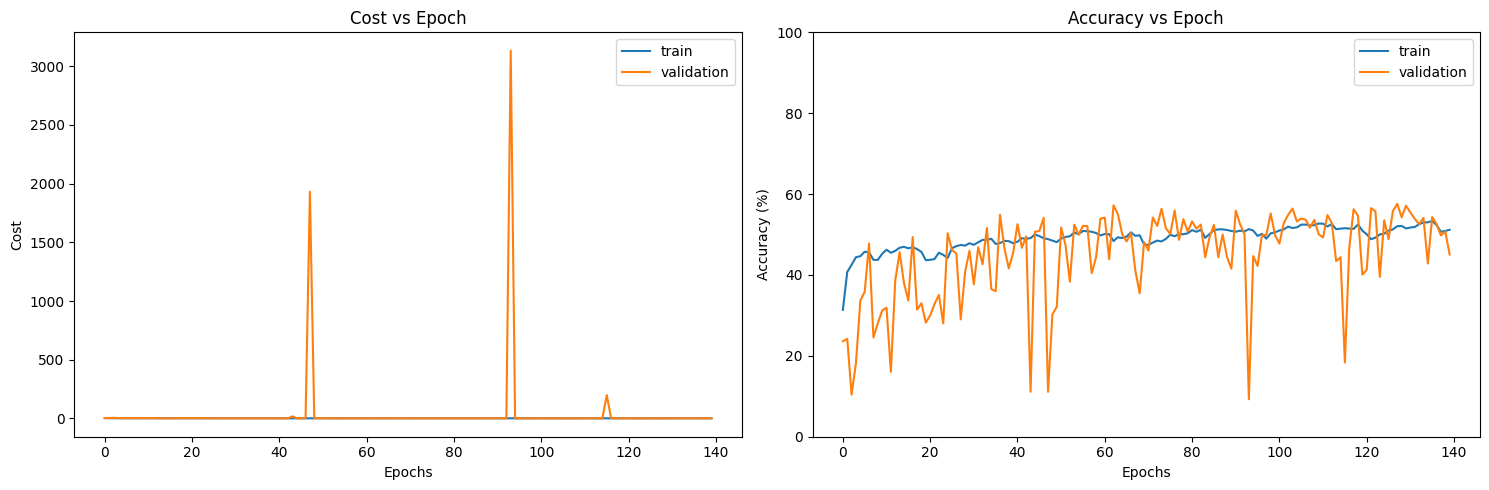

Training Accuracy: 51.17%
Validation Accuracy: 45.06%


In [48]:
train_costs_tf = history.history['loss']      
val_costs_tf = history.history['val_loss']  
train_acc_tf = history.history['accuracy']
val_acc_tf = history.history['val_accuracy']

# Get the final validation predictions
val_predictions_tf = model.predict(X_val_reshaped).argmax(axis=1)
plot_euro_sat_confusion_matrix(y_val, val_predictions_tf)

train_accs_percent = [acc * 100 for acc in train_acc_tf]
val_accs_percent = [acc * 100 for acc in val_acc_tf]

plot_learning_curves(train_costs_tf, val_costs_tf, train_accs_percent, val_accs_percent)

print(f"Training Accuracy: {float(train_acc_tf[-1]*100):.2f}%")
print(f"Validation Accuracy: {float(val_acc_tf[-1]*100):.2f}%")

### Test Accuracy for TF

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4471 - loss: 1.6756
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


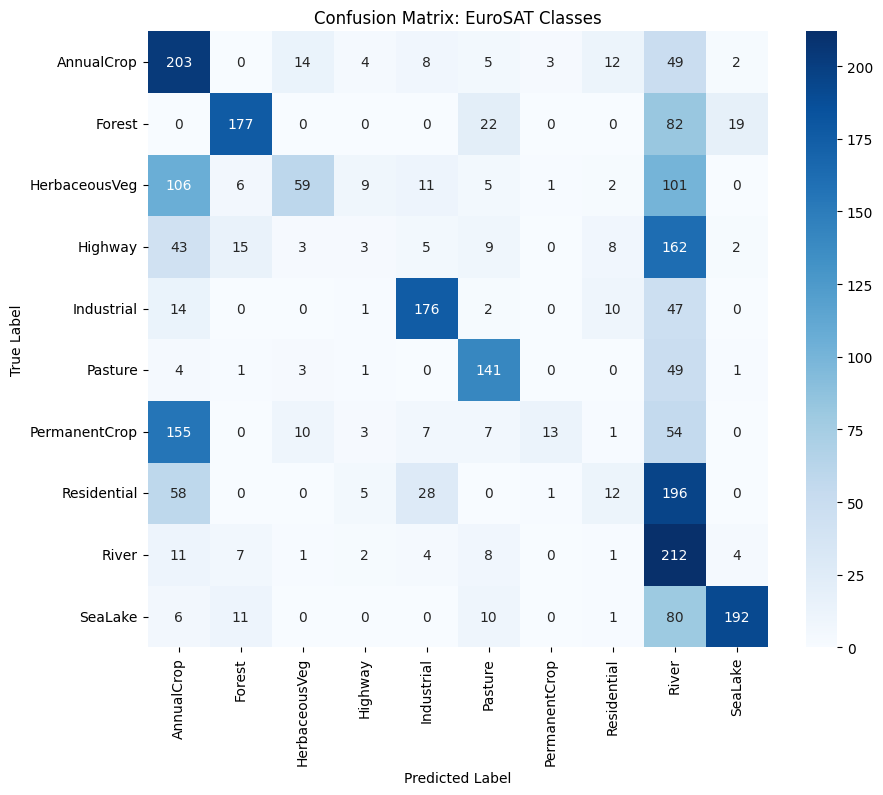

Test Accuracy: 44.00%


In [49]:
test_loss, test_acc = model.evaluate(X_test_reshaped, enc_y_test_transposed)

test_predictions_tf = model.predict(X_test_reshaped).argmax(axis=1)

plot_euro_sat_confusion_matrix(y_test, test_predictions_tf)

print(f"Test Accuracy: {test_acc*100:.2f}%")

In [50]:
model.save('models/DNN_tf.h5')

with open('DNN_tf_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)